# SHAP — what our SD-CNN actually reads

Two models, one drug, one question: **when the SD-CNN is handed protein +
biophysical + regulatory alongside the DNA, does it use them?**

| cell | run folder | weights stem | blocks |
|---|---|---|---|
| **DNA-only** | `full_run_v2/dna__mdcnn` | `{DRUG}__dna` | `dna:{locus}` per locus |
| **All modalities** | `full_run_v2/all_modalities__mdcnn` | `{DRUG}__dna+protein+biophysical+regulatory` | 4 modalities × per locus |

`mdcnn` is the architecture — BIG-TB's own SD-CNN topology (loci stacked as
channels, 12-bp conv from layer 1). Single-drug: one model per drug, `out_dim=1`.
The other three architectures in `full_run_v2` (`late_fusion`, `setfusion`,
`cisfusion`) are out of scope here.

**Attribution method: `shap.GradientExplainer`** (expected gradients). Not
`DeepExplainer` — that needs a registered handler per op and dies on anything
past plain conv/relu/linear. GradientExplainer only needs autograd.

**What is being explained.** The model emits ONE logit; `training.multimodal`
applies `sigmoid` outside it, and the label convention is `y: 0=R, 1=S`, so the
logit is *log-odds of SUSCEPTIBLE*. Every plot below is sign-flipped
(`RESISTANCE_SIGN = -1`) so **positive = pushes the call toward RESISTANT**.

**Layout.** Part I (sections 1-8) is one drug, interactive: config → load models
→ rebuild the held-out split → *reproduce the reported test AUC* (never trust an
attribution from a model you have not re-scored) → SHAP → per-modality budget →
per-position profiles → the DNA-only vs all-modalities diff.

**Part II (9-11)** is the 11-drug sweep, and is where the attribution is checked
against the ablation runs rather than believed on its own. **Part III (12-15)**
turns to the JOINT model and asks whether it reads the right locus for the right
drug. Parts II and III read CSVs written by `scripts/shap_attribution.py` and
`scripts/shap_multidrug.py`, so they run in seconds and need no models loaded.

In [45]:
import gc
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import shap
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, average_precision_score
from IPython.display import display

# this notebook lives in <project>/notebooks/; put the project root on the path
PROJECT = next(p for p in [Path("/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion"),
                           Path.cwd().parent, Path.cwd()]
               if (p / "training" / "checkpoint.py").exists())
sys.path.insert(0, str(PROJECT))

from datasets import load_dataset                             # noqa: E402
from training.checkpoint import load_model, run_weights_dir   # noqa: E402

EXP_DIR = PROJECT / "results" / "experiments"
print("project:", PROJECT)
print("shap", shap.__version__, "| torch", torch.__version__,
      "| cuda", torch.cuda.is_available())

project: /home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion
shap 0.52.0 | torch 2.6.0+cu124 | cuda False


In [46]:
# --- config ----------------------------------------------------------------
RUN = "full_run_v2"          # the run whose weights exist on the shared volume
ARCH = "mdcnn"               # SD-CNN topology. This notebook is only about mdcnn.
DRUG = "ISONIAZID"           # 2 loci (inhA, katG), 17.4k valid isolates
FOLD = None                  # None -> config's best_fold, the model TEST was scored on

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# SHAP cost is O(N_EXPLAIN * NSAMPLES) forward+backward passes.
N_BACKGROUND = 100           # reference isolates drawn from the TRAIN side of the split
N_EXPLAIN    = 200           # held-out isolates actually attributed
NSAMPLES     = 512            # expected-gradient samples per explained isolate
SEED         = 42

RESISTANCE_SIGN = -1         # logit is log-odds(SUSCEPTIBLE); flip so + == toward RESISTANT

CACHE_DIR = PROJECT / "results" / "analysis" / "shap" / RUN / ARCH / DRUG
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# the two cells being compared. `run_name` is the weights-volume key
# ({RUN}/{cell}); `dir` is the results folder holding summary.csv + the pointer.
CELLS = {
    "DNA only":       {"run_name": f"{RUN}/dna__{ARCH}",
                       "dir": EXP_DIR / RUN / f"dna__{ARCH}"},
    "All modalities": {"run_name": f"{RUN}/all_modalities__{ARCH}",
                       "dir": EXP_DIR / RUN / f"all_modalities__{ARCH}"},
}
for _c in CELLS.values():
    assert _c["dir"].is_dir(), f"no such run folder: {_c['dir']}"
MOD_ORDER = ["dna", "protein", "biophysical", "regulatory"]
MOD_COLOR = dict(zip(MOD_ORDER, ["#3B6FA0", "#C4703A", "#5E8C5A", "#8A5FA8"]))

# One generator PER PURPOSE, each seeded independently. A single shared `rng`
# made `pick` depend on how many draws happened before it — including whether a
# SHAP cache hit skipped a draw — so the explained isolates silently changed
# between a cold and a warm run.
rng_bg = np.random.default_rng(SEED)
rng_pick = np.random.default_rng(SEED + 1)

# Rebuilt models are re-scored on GPU; conv nondeterminism moves AUC by ~1e-3 on
# the small drugs (AMIKACIN test n=741). This gate exists to catch a WRONG
# rebuild — wrong block order, wrong split — which lands nowhere near. Matches
# scripts/shap_attribution.py --auc-tol.
AUC_TOL = 5e-3
print(f"{DRUG} | {RUN}/{{dna,all_modalities}}__{ARCH} | device={DEVICE}")
print("cache:", CACHE_DIR)

ISONIAZID | full_run_v2/{dna,all_modalities}__mdcnn | device=cpu
cache: /home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/analysis/shap/full_run_v2/mdcnn/ISONIAZID


## 1. Load the two models

`load_model(run_name, stem)` rebuilds the net from `config.json` and loads the
saved fold — the checkpoint carries block order, head shape and `drug_names`,
none of which a bare `.pt` has. `stem` is discovered from the run folder's
`weights_location.json` rather than hardcoded, so a re-run with a different
modality tag still resolves.

In [47]:
def resolve_stem(run_dir, drug):
    """The {DRUG}__{tag} weights stem for this drug, read off the run's pointer file."""
    pointer = json.loads((run_dir / "weights_location.json").read_text())
    hits = [k for k in pointer if k.startswith(f"{drug}__")]
    if len(hits) != 1:
        raise KeyError(f"{drug} in {run_dir.name}: expected 1 stem, got {hits}")
    return hits[0]


models, configs = {}, {}
for name, c in CELLS.items():
    stem = resolve_stem(c["dir"], DRUG)
    model, cfg = load_model(c["run_name"], stem, fold=FOLD, map_location=DEVICE)
    models[name], configs[name] = model.to(DEVICE).eval(), cfg
    c.update(stem=stem, weights=run_weights_dir(c["run_name"], stem))

display(pd.DataFrame([{
    "cell": name, "arch": cfg["model"]["arch"], "params": cfg["model"]["n_params"],
    "blocks": len(cfg["model"]["blocks"]), "fold scored": cfg["best_fold"],
    "modalities": "+".join(cfg["data"]["modalities_used"]),
    "loci": "+".join(cfg["data"]["gene_order"]),
    "n_valid": cfg["data"]["n_valid"],
} for name, cfg in configs.items()]).set_index("cell"))

for name, cfg in configs.items():
    print(f"\n{name}:")
    for b in cfg["model"]["blocks"]:
        chans = ",".join(b["channel_names"][:6])
        print(f"  {b['name']:<24} ({b['channels']:>2} ch x {b['length']:>4} pos)  "
              f"{chans}{'...' if len(b['channel_names']) > 6 else ''}")

,arch,params,blocks,fold scored,modalities,loci,n_valid
cell,,,,,,,
DNA only,mdcnn,2360769,2,3,dna,inhA+katG,17436
All modalities,mdcnn,3798849,8,3,dna+protein+biophysical+regulatory,inhA+katG,17436



DNA only:
  dna:inhA                 ( 5 ch x  910 pos)  A,C,T,G,-
  dna:katG                 ( 5 ch x 2488 pos)  A,C,T,G,-

All modalities:
  dna:inhA                 ( 5 ch x  910 pos)  A,C,T,G,-
  dna:katG                 ( 5 ch x 2488 pos)  A,C,T,G,-
  protein:inhA             (20 ch x  269 pos)  A,C,D,E,F,G...
  protein:katG             (20 ch x  741 pos)  A,C,D,E,F,G...
  biophysical:inhA         ( 3 ch x  269 pos)  molecular_weight,isoelectric_point,hydrophobicity
  biophysical:katG         ( 3 ch x  741 pos)  molecular_weight,isoelectric_point,hydrophobicity
  regulatory:inhA          ( 5 ch x  879 pos)  A,C,T,G,-
  regulatory:katG          ( 5 ch x  642 pos)  A,C,T,G,-


## 2. Rebuild the exact inputs and the exact held-out split

`config['data']` records every loader switch (`per_modality_branch`,
`all_regulatory`, `extra_loci`, the resolved locus lists) and `config['split']`
records the **test isolate IDs verbatim** — not just "seed 42" — so this
reconstruction survives scikit-learn changing its shuffling.

Order matters: `run_modal_cv` drops missing-phenotype rows (`y == -1`) *before*
splitting, so that filter is reapplied here before indexing. `isolates.txt` in
the weights folder is that post-filter order and is asserted against below.

> **RAM.** These are full float32 one-hot arrays — all-modalities ISONIAZID is
> ~190 KB/isolate, ~3.4 GB for all 17.9k. The frame is sliced to the test split
> and the rest freed immediately.

In [48]:
def rebuild_inputs(cfg, weights_dir):
    """Reload this checkpoint's inputs, sliced to its own held-out test split.

    Mirrors scripts/run_experiment.py -> load_dataset, then
    training.multimodal.run_modal_cv's `keep = y != -1` filter."""
    d = cfg["data"]
    data = load_dataset(
        cfg["drug"], d["modalities_requested"],
        d["genotype_dir"], d["phenotype_csv"], regulatory_dir=d["regulatory_dir"],
        loci=d["loci_override"], regulatory_loci=d["regulatory_loci_override"],
        per_modality_branch=d["per_modality_branch"],
        extra_loci=d["extra_loci"], all_regulatory=d["all_regulatory"], verbose=False)

    keep = np.nonzero(data.y != -1)[0]
    y = data.y[keep]
    ids = np.asarray(data.isolate_ids, dtype=object)[keep]
    arrays = [a[keep] for a in data.arrays()]

    # the checkpoint's own record of this order — cheap proof the rebuild lines up
    saved = (Path(weights_dir) / "isolates.txt").read_text().split()
    assert list(ids) == saved, "isolate order drifted from the checkpoint's isolates.txt"

    pos = {s: i for i, s in enumerate(ids)}
    test_idx = np.array([pos[s] for s in cfg["split"]["test_isolate_ids"]])
    train_idx = np.setdiff1d(np.arange(len(ids)), test_idx)   # the CV pool
    bg_pick = rng_bg.choice(train_idx, size=min(N_BACKGROUND, len(train_idx)), replace=False)

    out = {"test": [np.ascontiguousarray(a[test_idx]) for a in arrays],
           "bg": [np.ascontiguousarray(a[bg_pick]) for a in arrays],
           "y": y[test_idx], "ids": ids[test_idx],
           "block_names": [b["name"] for b in cfg["model"]["blocks"]]}
    del data, arrays
    gc.collect()
    return out


inputs = {}
for name, c in CELLS.items():
    inputs[name] = rebuild_inputs(configs[name], c["weights"])
    d = inputs[name]
    print(f"{name:<16} test n={len(d['y'])}  R={int((d['y'] == 0).sum())} "
          f"S={int((d['y'] == 1).sum())}  blocks={[a.shape for a in d['test']]}")

DNA only         test n=3488  R=1165 S=2323  blocks=[(3488, 5, 910), (3488, 5, 2488)]
All modalities   test n=3488  R=1165 S=2323  blocks=[(3488, 5, 910), (3488, 5, 2488), (3488, 20, 269), (3488, 20, 741), (3488, 3, 269), (3488, 3, 741), (3488, 5, 879), (3488, 5, 642)]


## 3. Sanity check — reproduce the reported test AUC

A SHAP plot off a model that was rebuilt wrong is a plausible-looking lie. This
re-scores the loaded weights on the reconstructed held-out split and checks the
number against `summary.csv`. **If `delta` is not ~0, stop here** — the rebuild,
not the attribution, is what needs fixing.

In [49]:
@torch.no_grad()
def predict(model, arrays, batch=128):
    """P(susceptible) per row — the same path as training.multimodal._predict."""
    out = []
    for s in range(0, len(arrays[0]), batch):
        xs = [torch.from_numpy(a[s:s + batch]).to(DEVICE).float() for a in arrays]
        out.append(torch.sigmoid(model(xs)).cpu().numpy().reshape(-1))
    return np.concatenate(out)


check = []
for name, c in CELLS.items():
    d = inputs[name]
    d["p_susceptible"] = predict(models[name], d["test"])
    reported = (pd.read_csv(c["dir"] / "summary.csv")
                .set_index("drug").loc[DRUG, "test_auc"])
    got = roc_auc_score(d["y"], d["p_susceptible"])
    check.append({"cell": name, "reported test AUC": reported, "recomputed": got,
                  "delta": got - reported,
                  "test AUC-PR (R=pos)": average_precision_score(1 - d["y"],
                                                                1 - d["p_susceptible"])})

display(pd.DataFrame(check).set_index("cell").round(4))
worst = np.abs([r["delta"] for r in check]).max()
assert worst < AUC_TOL, f"rebuild does not reproduce the run (worst delta {worst:.4f})"
print(f"OK — both models reproduce their reported test AUC (worst {worst:+.5f}).")

,reported test AUC,recomputed,delta,test AUC-PR (R=pos)
cell,,,,
DNA only,0.9264,0.9263,-0.0001,0.9042
All modalities,0.9767,0.9766,-0.0001,0.9618


OK — both models reproduce their reported test AUC (worst +0.00014).


## 4. SHAP values

`GradientExplainer` passes inputs positionally, the nets take one list, hence
`Wrap`. Returned arrays are `(n_explained, channels, length, n_outputs)`;
`n_outputs` is 1 here and gets squeezed.

**Collapsing channels.** The inputs are one-hot (DNA / protein / regulatory), so
the only channel that is "on" at a position is the observed base/residue. The
per-position contribution is therefore `(shap * x).sum(axis=channel)` — the
attribution of *what this isolate actually has there*, not a sum over
counterfactual alleles. That form is also correct for the continuous
biophysical channels, so one expression covers every block.

Results cache to `results/analysis/shap/` — recomputing is minutes, not seconds.

In [50]:
class Wrap(torch.nn.Module):
    """GradientExplainer passes inputs positionally; the nets take one list."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, *xs):
        return self.model(list(xs))


def shap_for(name, force=False):
    """Per-block SHAP arrays for N_EXPLAIN held-out isolates, oriented toward RESISTANT."""
    # The filename carries NSAMPLES/N_EXPLAIN/SEED because those DETERMINE the
    # contents. A bare "{cell}__shap.npz" silently served a 64-sample result
    # after NSAMPLES was raised to 512 — the config cell said one thing and the
    # figures showed another, which is the exact failure this notebook keeps
    # warning about elsewhere.
    tag = f"n{N_EXPLAIN}_s{NSAMPLES}_bg{N_BACKGROUND}_seed{SEED}"
    cache = CACHE_DIR / f"{CELLS[name]['dir'].name}__shap__{tag}.npz"
    d = inputs[name]
    if cache.exists() and not force:
        z = np.load(cache, allow_pickle=True)
        print(f"  {name}: cache hit ({tag})")
        return [z[f"b{i}"] for i in range(len(d["block_names"]))], z["pick"]

    # rng_pick, not the shared rng: the isolates explained must not depend on
    # whether the OTHER cell hit its cache
    pick = rng_pick.choice(len(d["y"]), size=min(N_EXPLAIN, len(d["y"])),
                           replace=False)
    explainer = shap.GradientExplainer(
        Wrap(models[name]),
        [torch.from_numpy(a).to(DEVICE).float() for a in d["bg"]])
    raw = explainer.shap_values(
        [torch.from_numpy(a[pick]).to(DEVICE).float() for a in d["test"]],
        nsamples=NSAMPLES)

    # (n, C, L, 1) -> (n, C, L), then flip sign so + == toward RESISTANT
    sv = [RESISTANCE_SIGN * np.asarray(r).squeeze(-1) for r in raw]
    np.savez_compressed(cache, pick=pick, **{f"b{i}": s for i, s in enumerate(sv)})
    return sv, pick


shap_vals, picks, contrib = {}, {}, {}
for name in CELLS:
    shap_vals[name], picks[name] = shap_for(name)
    # (n, C, L) SHAP x (n, C, L) input -> (n, L) contribution of the OBSERVED value
    contrib[name] = [(s * a[picks[name]]).sum(axis=1)
                     for s, a in zip(shap_vals[name], inputs[name]["test"])]
    print(f"{name:<16} {len(picks[name])} isolates, "
          f"blocks: {[c.shape for c in contrib[name]]}")

KeyboardInterrupt: 

## 5. The headline — where does the attribution budget go?

Per block: `mean over isolates of sum_positions |contribution|`, rolled up by
modality and normalised to a share of the total. The DNA-only model is a
degenerate 100% bar by construction; the point is what the all-modalities model
does with the other three.

**Read it as a budget, not as proof of use.** A modality can take a share of the
gradient and still add no discriminative signal. Section 7 checks whether the
DNA branch itself moved; **sections 9-10 are the checks that settle it**, by
putting these shares against what the ablation runs actually measure.


=== DNA only


,modality,locus,length,mean |attr|,mean signed attr,share
block,,,,,,
dna:inhA,dna,inhA,910,1.189e-01,-6.564e-02,6.9%
dna:katG,dna,katG,2488,1.609e+00,+1.420e-01,93.1%



=== All modalities


,modality,locus,length,mean |attr|,mean signed attr,share
block,,,,,,
dna:inhA,dna,inhA,910,4.460e-04,+3.378e-04,0.0%
dna:katG,dna,katG,2488,3.687e-02,+3.127e-03,1.0%
protein:inhA,protein,inhA,269,1.119e-01,+4.473e-02,3.1%
protein:katG,protein,katG,741,1.934e+00,-3.828e-01,53.9%
biophysical:inhA,biophysical,inhA,269,4.208e-04,-3.773e-04,0.0%
biophysical:katG,biophysical,katG,741,1.272e+00,+4.228e-01,35.5%
regulatory:inhA,regulatory,inhA,879,1.961e-01,-4.423e-02,5.5%
regulatory:katG,regulatory,katG,642,3.647e-02,-1.146e-02,1.0%


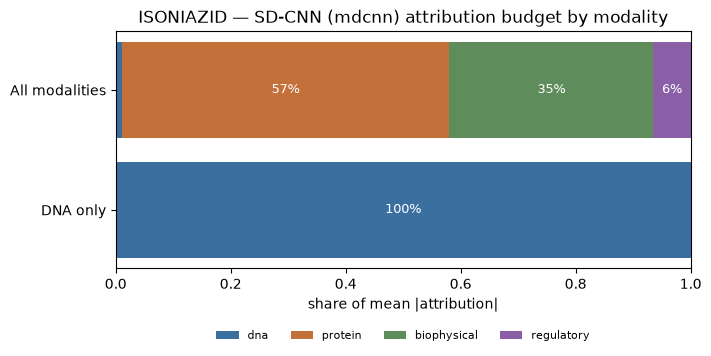

In [ ]:
def block_budget(name):
    t = pd.DataFrame([
        {"block": b["name"], "modality": b["modality"], "locus": b["locus"],
         "length": b["length"],
         "mean |attr|": float(np.abs(c).sum(axis=1).mean()),
         "mean signed attr": float(c.sum(axis=1).mean())}
        for b, c in zip(configs[name]["model"]["blocks"], contrib[name])])
    t["share"] = t["mean |attr|"] / t["mean |attr|"].sum()
    return t


budgets = {n: block_budget(n) for n in CELLS}
# raw attributions are ~1e-5 and round to 0.0000 — show them in exponent form and
# read the comparisons off `share`, which is what is actually scale-free
FMT = {"mean |attr|": "{:.3e}", "mean signed attr": "{:+.3e}", "share": "{:.1%}"}
for n, t in budgets.items():
    print(f"\n=== {n}")
    display(t.set_index("block").style.format(FMT))

# a block the model gives literally nothing to is worth calling out by name
for n, t in budgets.items():
    dead = t.loc[t["share"] < 1e-6, "block"].tolist()
    if dead:
        print(f"\n{n}: blocks with ~zero attribution (model ignores them): {dead}")

by_mod = pd.DataFrame({n: t.groupby("modality")["share"].sum()
                       for n, t in budgets.items()}).reindex(MOD_ORDER).fillna(0.0)

fig, ax = plt.subplots(figsize=(7, 3.4), constrained_layout=True)
left = np.zeros(len(by_mod.columns))
for mod in MOD_ORDER:
    v = by_mod.loc[mod].values
    ax.barh(list(by_mod.columns), v, left=left, color=MOD_COLOR[mod], label=mod)
    for i, (x, w) in enumerate(zip(left, v)):
        if w > 0.04:
            ax.text(x + w / 2, i, f"{w:.0%}", ha="center", va="center",
                    color="white", fontsize=9)
    left += v
ax.set_xlim(0, 1)
ax.set_xlabel("share of mean |attribution|")
ax.set_title(f"{DRUG} — SD-CNN ({ARCH}) attribution budget by modality")
ax.legend(ncol=4, fontsize=8, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.35))
plt.show()

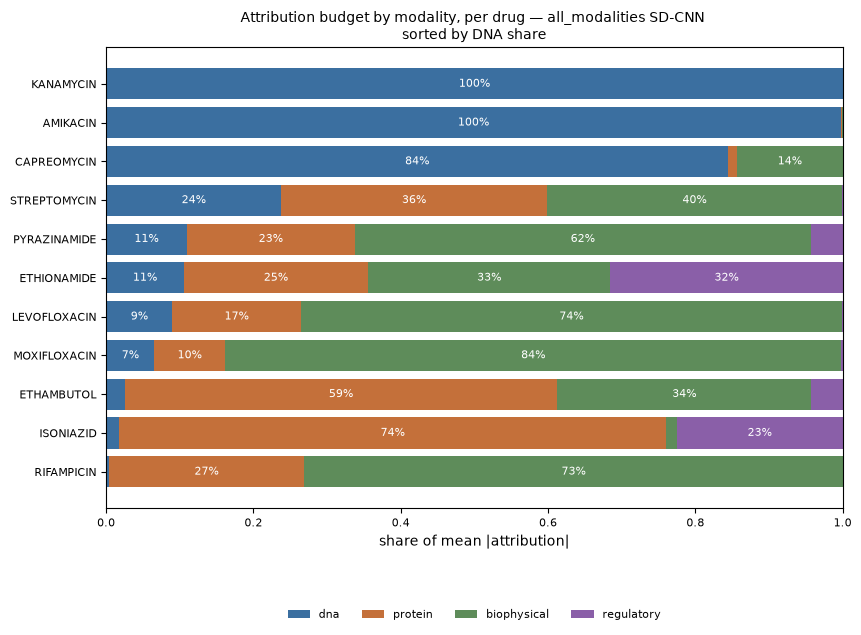

modality,dna,protein,biophysical,regulatory
drug,,,,
KANAMYCIN,100.0%,0.0%,0.0%,0.0%
AMIKACIN,99.7%,0.2%,0.1%,0.0%
CAPREOMYCIN,84.4%,1.2%,14.4%,0.0%
STREPTOMYCIN,23.8%,36.0%,40.1%,0.1%
PYRAZINAMIDE,11.0%,22.8%,61.9%,4.3%
ETHIONAMIDE,10.5%,25.0%,32.9%,31.5%
LEVOFLOXACIN,9.0%,17.4%,73.5%,0.1%
MOXIFLOXACIN,6.6%,9.6%,83.7%,0.2%
ETHAMBUTOL,2.5%,58.7%,34.5%,4.3%


In [52]:
# --- modality budget, drug by drug -----------------------------------------
# Section 5's chart for all 11 drugs at once, from the all-modalities model (the
# only cell that sees every modality, so the only one whose split means
# anything). Sorted by DNA share: that ordering is the result — the rRNA drugs
# pile up at the top and the protein-coding targets at the bottom.
MD_CELL = "all_modalities"

by_drug = (sweep[sweep["cell"] == MD_CELL]
           .groupby(["drug", "modality"])["share"].sum()
           .unstack(fill_value=0.0)
           .reindex(columns=MOD_ORDER, fill_value=0.0))
by_drug = by_drug.div(by_drug.sum(axis=1), axis=0)          # rows sum to 1
by_drug = by_drug.sort_values("dna", ascending=True)        # barh draws bottom-up

fig, ax = plt.subplots(figsize=(8.5, 0.42 * len(by_drug) + 1.6),
                       constrained_layout=True)
left = np.zeros(len(by_drug))
for mod in MOD_ORDER:
    v = by_drug[mod].values
    ax.barh(by_drug.index, v, left=left, color=MOD_COLOR[mod], label=mod)
    for i, (x, w) in enumerate(zip(left, v)):
        if w > 0.06:                        # below this the label will not fit
            ax.text(x + w / 2, i, f"{w:.0%}", ha="center", va="center",
                    color="white", fontsize=8)
    left += v
ax.set_xlim(0, 1)
ax.set_xlabel("share of mean |attribution|")
ax.set_ylabel("")
ax.tick_params(labelsize=8)
ax.set_title(f"Attribution budget by modality, per drug — {MD_CELL} SD-CNN \n"
             f"sorted by DNA share", fontsize=10)
ax.legend(ncol=4, fontsize=8, frameon=False, loc="lower center",
          bbox_to_anchor=(0.5, -0.22 - 0.5 / len(by_drug)))
plt.show()

display(by_drug.iloc[::-1].style.format("{:.1%}")
        .background_gradient(cmap="Blues", vmin=0, vmax=1))


## 6. Per-position profile along each locus

Mean |contribution| per alignment column. Peaks are the columns the model keys
on; a flat profile means it is spreading itself over the whole locus, which for
a resistance gene is a bad sign.

> Positions are **alignment columns in the MSA on disk**, not H37Rv coordinates
> — resolving a peak to a codon means walking `datasets/sequences.py`'s
> alignment back to the reference. Left as a TODO below.

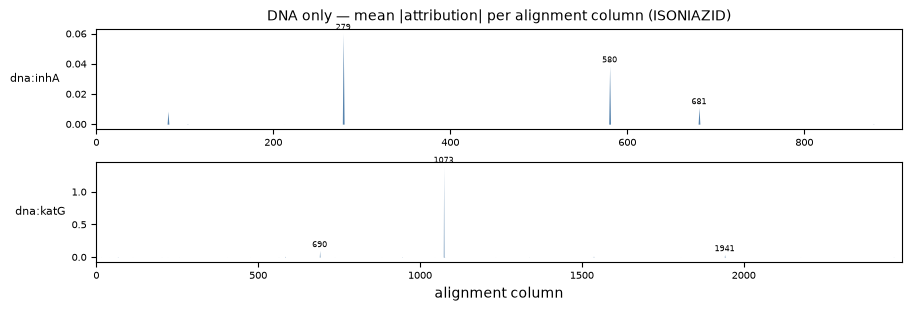


=== DNA only — highest-attribution columns (+ signed == toward RESISTANT)


,block,position,mean |attr|,share of block,mean signed attr
0,dna:katG,1073,1.393e+00,86.61%,+2.669e-01
1,dna:katG,690,1.008e-01,6.27%,-1.008e-01
2,dna:inhA,279,6.033e-02,50.73%,-2.908e-02
3,dna:katG,1941,3.890e-02,2.42%,-3.890e-02
4,dna:inhA,580,3.873e-02,32.57%,-3.873e-02
5,dna:katG,1536,1.651e-02,1.03%,+6.892e-03
6,dna:katG,1074,1.403e-02,0.87%,-3.128e-03
7,dna:katG,583,1.367e-02,0.85%,+1.367e-02
8,dna:inhA,681,1.099e-02,9.24%,+1.099e-02
9,dna:inhA,81,8.568e-03,7.20%,-8.561e-03


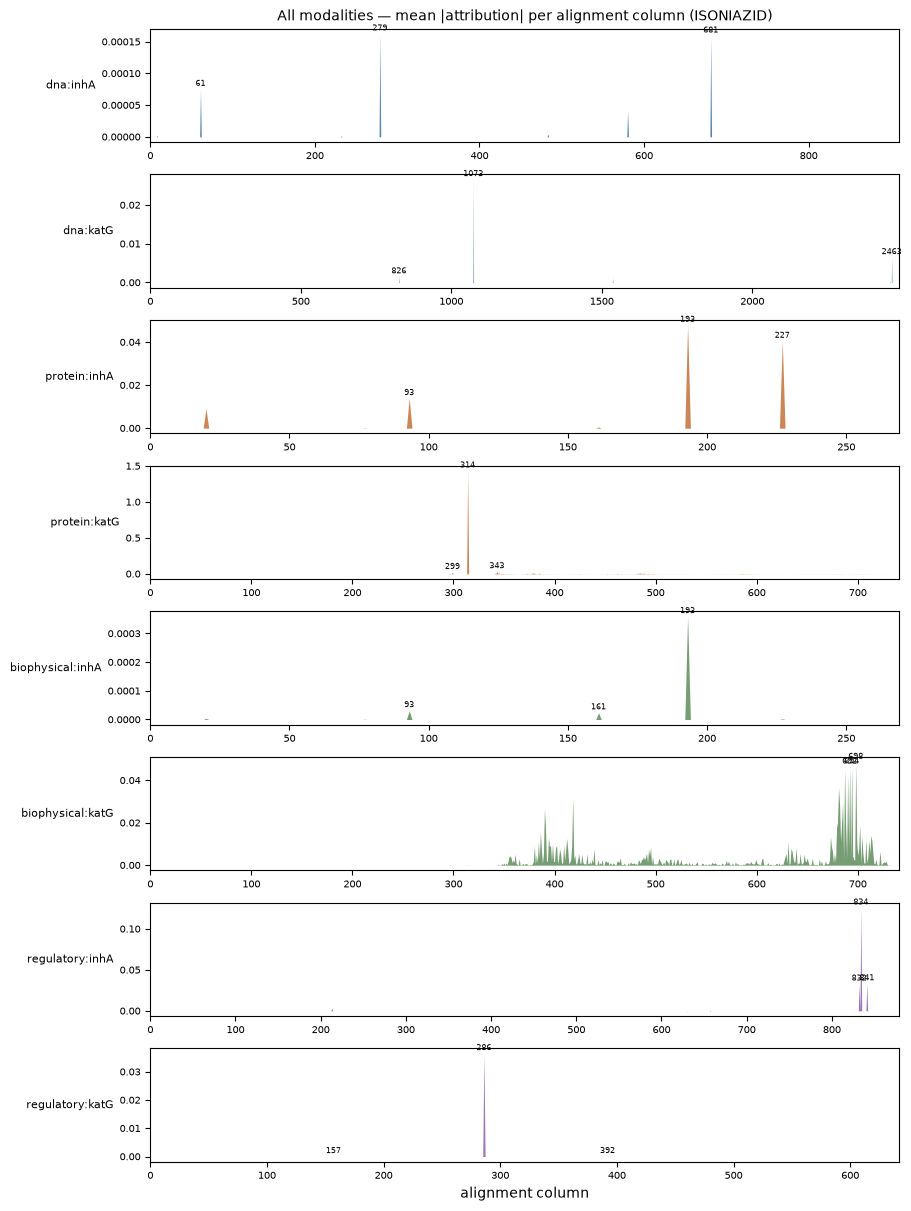


=== All modalities — highest-attribution columns (+ signed == toward RESISTANT)


,block,position,mean |attr|,share of block,mean signed attr
0,protein:katG,314,1.432e+00,74.05%,-4.429e-01
1,regulatory:inhA,834,1.256e-01,64.06%,-6.892e-03
2,biophysical:katG,698,4.855e-02,3.82%,+4.854e-02
3,protein:inhA,193,4.788e-02,42.79%,+9.650e-03
4,biophysical:katG,694,4.637e-02,3.64%,+4.637e-02
5,biophysical:katG,692,4.628e-02,3.64%,+4.628e-02
6,biophysical:katG,687,4.531e-02,3.56%,+4.531e-02
7,biophysical:katG,690,4.237e-02,3.33%,+4.237e-02
8,protein:inhA,227,4.043e-02,36.14%,+3.287e-02
9,biophysical:katG,681,3.659e-02,2.88%,+3.658e-02


In [ ]:
def norm(v):
    """Share-normalise a profile. A block the model ignores outright sums to 0 —
    that is a result, not an error, so it returns zeros rather than nan."""
    tot = v.sum()
    return v / tot if tot > 0 else np.zeros_like(v)


def profile_plot(name, top_k=8):
    blocks = configs[name]["model"]["blocks"]
    fig, axes = plt.subplots(len(blocks), 1, figsize=(9, 1.5 * len(blocks)),
                             constrained_layout=True, squeeze=False)
    tops = []
    for ax, b, c in zip(axes[:, 0], blocks, contrib[name]):
        prof = np.abs(c).mean(axis=0)
        ax.fill_between(np.arange(len(prof)), prof, color=MOD_COLOR[b["modality"]],
                        lw=0, alpha=0.85)
        ax.set_ylabel(b["name"], fontsize=8, rotation=0, ha="right", va="center")
        ax.set_xlim(0, len(prof))
        ax.tick_params(labelsize=7)
        hits = np.argsort(prof)[::-1][:top_k]
        for h in hits[:3]:
            ax.annotate(str(h), (h, prof[h]), fontsize=6, ha="center", va="bottom",
                        xytext=(0, 1), textcoords="offset points")
        tops += [{"block": b["name"], "position": int(h), "mean |attr|": float(prof[h]),
                  "share of block": float(norm(prof)[h]),
                  "mean signed attr": float(c[:, h].mean())} for h in hits]
    axes[0, 0].set_title(f"{name} — mean |attribution| per alignment column ({DRUG})",
                         fontsize=10)
    axes[-1, 0].set_xlabel("alignment column")
    plt.show()
    return (pd.DataFrame(tops).sort_values("mean |attr|", ascending=False)
            .reset_index(drop=True))


top_positions = {}
for name in CELLS:
    top_positions[name] = profile_plot(name)
    print(f"\n=== {name} — highest-attribution columns (+ signed == toward RESISTANT)")
    display(top_positions[name].head(12).style.format(
        {"mean |attr|": "{:.3e}", "share of block": "{:.2%}",
         "mean signed attr": "{:+.3e}"}))

## 7. Does the extra data change what the DNA branch reads?

Both models share the `dna:{locus}` blocks position-for-position, so their
profiles subtract. Three outcomes:

- **profiles overlap, extra modalities take a small share** — the extra data is
  decoration; the DNA-only model is the honest one to report.
- **profiles overlap, extra modalities take a large share** — the model found a
  redundant re-encoding of the same variants. protein and biophysical are both
  *derived from* the DNA, so this is the null hypothesis, not a discovery.
- **profiles differ** — the extra channels genuinely moved what the DNA branch
  keys on. That is the only outcome worth writing up.

KeyError: 'DNA only'

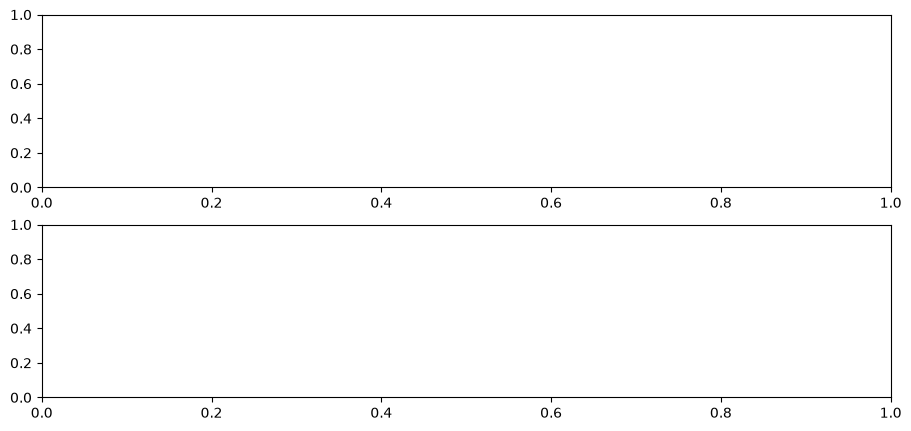

In [53]:
dna_blocks = [b["name"] for b in configs["DNA only"]["model"]["blocks"]]
idx_all = {b["name"]: i for i, b in enumerate(configs["All modalities"]["model"]["blocks"])}

fig, axes = plt.subplots(len(dna_blocks), 1, figsize=(9, 2.1 * len(dna_blocks)),
                         constrained_layout=True, squeeze=False)
corr = []
for ax, block in zip(axes[:, 0], dna_blocks):
    # share-normalised: the two models differ in absolute attribution scale
    solo = norm(np.abs(contrib["DNA only"][dna_blocks.index(block)]).mean(axis=0))
    full = norm(np.abs(contrib["All modalities"][idx_all[block]]).mean(axis=0))
    ax.plot(solo, lw=0.8, color="#3B6FA0", label="DNA only")
    ax.plot(-full, lw=0.8, color="#C4703A", label="All modalities")
    ax.axhline(0, lw=0.5, color="0.4")
    ax.set_ylabel(block, fontsize=8, rotation=0, ha="right", va="center")
    ax.set_xlim(0, len(solo))
    ax.tick_params(labelsize=7)
    # Pearson on a spiky profile measures the spike and nothing else: katG is
    # 87% one column, so r=0.97 was a one-point correlation while the top-20
    # overlap was 0.25. Rank the columns instead, and report the tail separately
    # from the peaks.
    order = np.argsort(solo)[::-1]
    tail = order[10:]                       # everything below the top 10 columns
    corr.append({"block": block,
                 "spearman (all columns)": float(spearmanr(solo, full).statistic),
                 "spearman (tail, excl. top 10)": float(
                     spearmanr(solo[tail], full[tail]).statistic),
                 "top-20 column overlap": len(set(order[:20])
                                              & set(np.argsort(full)[::-1][:20])) / 20})
axes[0, 0].legend(fontsize=8, frameon=False, ncol=2)
axes[0, 0].set_title(f"{DRUG} — DNA-branch attribution, mirrored", fontsize=10)
axes[-1, 0].set_xlabel("alignment column")
plt.show()

display(pd.DataFrame(corr).set_index("block").round(3))

## 8. Per-isolate view — do attributions line up with the call?

Sum of contributions per isolate against the model's own probability, split by
true phenotype. Total attribution should track the logit; isolates where it does
not are where the background baseline is doing the work instead of the input.

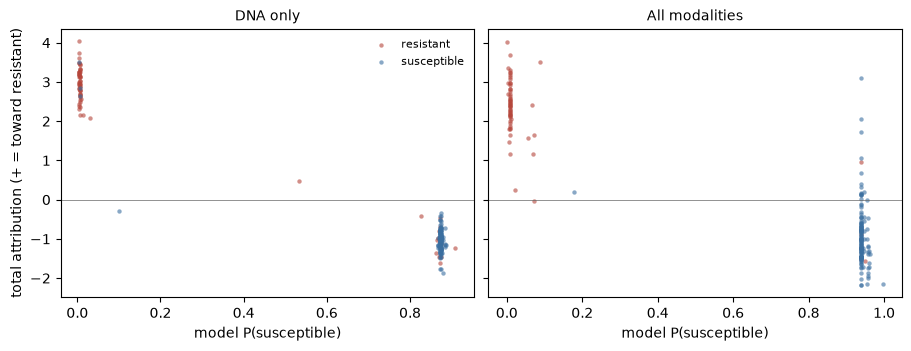

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True, sharey=True)
for ax, name in zip(axes, CELLS):
    d, pick = inputs[name], picks[name]
    total = np.sum([c.sum(axis=1) for c in contrib[name]], axis=0)
    y, p = d["y"][pick], d["p_susceptible"][pick]
    for lab, val, col in [("resistant", 0, "#B5453A"), ("susceptible", 1, "#3B6FA0")]:
        m = y == val
        ax.scatter(p[m], total[m], s=10, alpha=0.6, color=col, label=lab, lw=0)
    ax.axhline(0, lw=0.5, color="0.4")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("model P(susceptible)")
axes[0].set_ylabel("total attribution (+ = toward resistant)")
axes[0].legend(fontsize=8, frameon=False)
plt.show()

---

# Part II — the cross-drug sweep

Everything above is one drug, run interactively. `scripts/shap_attribution.py`
runs the identical procedure for all 11 drugs on GPU (`bash
results/analysis/shap/submit_shap.sh`, one job per drug) and writes per-drug
CSVs; the cells below only read those, so this half runs in seconds and needs
none of the models in memory.

**The question.** Section 5 measured how the attribution budget is split between
modalities. It never showed that a modality with a big share is doing anything
useful — a block can absorb gradient and still add no information. The ablation
runs answer that directly: `dna_protein` minus `dna` is what protein is actually
worth in CV AUC. Putting the two side by side is the real deliverable.

In [57]:
# --- load the sweep --------------------------------------------------------
SHAP_ROOT = PROJECT / "results" / "analysis" / "shap" / RUN / ARCH

block_files = sorted(SHAP_ROOT.glob("*/*__blocks.csv"))
if not block_files:
    raise FileNotFoundError(
        f"no sweep output in {SHAP_ROOT}. Run: bash results/analysis/shap/submit_shap.sh")
sweep = pd.concat([pd.read_csv(p) for p in block_files], ignore_index=True)

# attribution share per (drug, modality), from the all-modalities model — the
# only one that sees every modality and so the only one whose split is meaningful
share = (sweep[sweep["cell"] == "all_modalities"]
         .groupby(["drug", "modality"])["share"].sum().rename("share").reset_index())

# --- the ablation ladder, from whichever run folders exist ------------------
# full_run_v2 adds one modality at a time to DNA; shap_followup removes one from
# the full set (see results/experiments/shap_followup/README.md)
LADDER = {
    "dna": (RUN, "dna"), "dna_protein": (RUN, "dna_protein"),
    "dna_biophysical": (RUN, "dna_biophysical"),
    "dna_regulatory": (RUN, "dna_regulatory"),
    "all_modalities": (RUN, "all_modalities"),
    "no_dna": ("shap_followup", "no_dna"),
    "no_regulatory": ("shap_followup", "no_regulatory"),
    "regulatory_only": ("shap_followup", "regulatory_only"),
}
cv, missing = {}, []
for name, (run, cell) in LADDER.items():
    p = EXP_DIR / run / f"{cell}__{ARCH}" / "summary.csv"
    if not p.exists():
        missing.append(name)
        continue
    s = pd.read_csv(p).set_index("drug")
    cv[name] = s["cv_auc_mean"]
    cv[name + "__sd"] = s["cv_auc_std"]
cv = pd.DataFrame(cv)

print(f"sweep: {sweep['drug'].nunique()} drugs x {sweep['cell'].nunique()} cells "
      f"from {len(block_files)} file(s)")
if missing:
    print(f"ladder rungs not on disk yet (jobs still running?): {missing}")
print(f"ladder: {[c for c in cv.columns if not c.endswith('__sd')]}")

sweep: 11 drugs x 2 cells from 21 file(s)
ladder: ['dna', 'dna_protein', 'dna_biophysical', 'dna_regulatory', 'all_modalities', 'no_dna', 'no_regulatory', 'regulatory_only']


## 9. Attribution share vs. what the modality is actually worth

For each drug and each of the three non-DNA modalities:

- **share** — fraction of the all-modalities model's attribution budget.
- **Δ add** — `CV AUC(dna + modality) − CV AUC(dna)`. What it buys on top of DNA.
- **auc_lost_if_dropped** — `CV AUC(all) − CV AUC(all − modality)`. What is
  lost by removing it from the full set. Only defined where the `shap_followup`
  runs have landed.

**Sign convention, both columns and section 10: positive means the modality is
valuable.** `auc_lost_if_dropped = +0.32` for DNA on AMIKACIN reads "removing
DNA costs 0.32 AUC" — a loss, not a gain.

If attribution share tracked usefulness these would rank the same way. The
Spearman correlation across all (drug, modality) points is the summary number.

In [58]:
ADD = {"protein": "dna_protein", "biophysical": "dna_biophysical",
       "regulatory": "dna_regulatory"}
DROP = {"dna": "no_dna", "regulatory": "no_regulatory"}

rows = []
for _, r in share.iterrows():
    d, m = r["drug"], r["modality"]
    if d not in cv.index:
        continue
    add = (cv.at[d, ADD[m]] - cv.at[d, "dna"]
           if m in ADD and ADD[m] in cv.columns else np.nan)
    # SIGN CONVENTION, used identically in section 10: positive means the
    # modality is VALUABLE. `auc_lost_if_dropped` = CV(all) - CV(all minus m),
    # so +0.32 reads "removing DNA costs 0.32 AUC" — it is a loss, not a gain.
    lost = (cv.at[d, "all_modalities"] - cv.at[d, DROP[m]]
            if m in DROP and DROP[m] in cv.columns else np.nan)
    rows.append({"drug": d, "modality": m, "share": r["share"],
                 "delta_add": add, "auc_lost_if_dropped": lost,
                 "cv_dna": cv.at[d, "dna"], "cv_all": cv.at[d, "all_modalities"]})
comp = pd.DataFrame(rows).sort_values(["drug", "modality"])

paired = comp.dropna(subset=["delta_add"])
rho = spearmanr(paired["share"], paired["delta_add"])
print(f"Spearman(share, delta_add) over {len(paired)} (drug, modality) points: "
      f"rho={rho.statistic:+.3f}  p={rho.pvalue:.3f}")
for m, g in paired.groupby("modality"):
    r_m = spearmanr(g["share"], g["delta_add"])
    print(f"  {m:<12} n={len(g):>2}  rho={r_m.statistic:+.3f}  "
          f"median share={g['share'].median():.1%}  "
          f"median delta_add={g['delta_add'].median():+.4f}")

display(comp.set_index(["drug", "modality"]).style.format(
    {"share": "{:.1%}", "delta_add": "{:+.4f}", "auc_lost_if_dropped": "{:+.4f}",
     "cv_dna": "{:.4f}", "cv_all": "{:.4f}"}, na_rep="—"))

Spearman(share, delta_add) over 33 (drug, modality) points: rho=+0.480  p=0.005
  biophysical  n=11  rho=+0.055  median share=34.5%  median delta_add=+0.0067
  protein      n=11  rho=+0.232  median share=22.8%  median delta_add=+0.0054
  regulatory   n=11  rho=+0.709  median share=0.1%  median delta_add=+0.0015


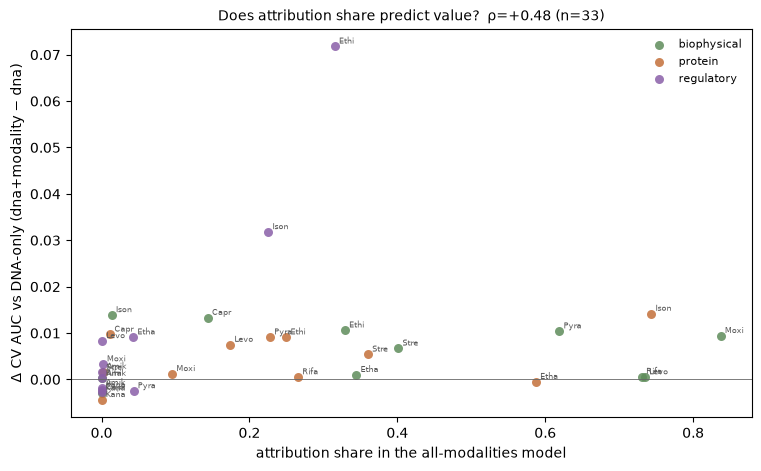

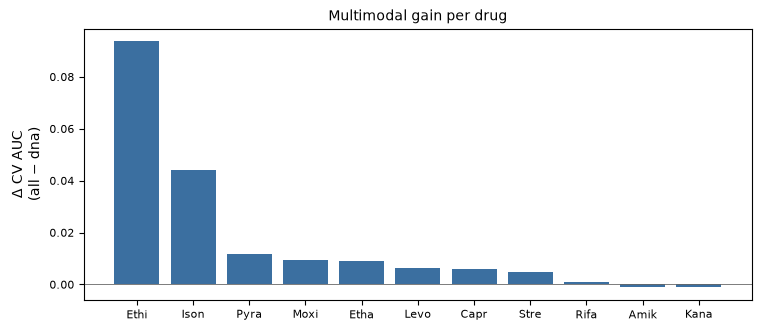

,cv dna,cv all,gain
drug,,,
ETHIONAMIDE,0.7071,0.8009,0.0938
ISONIAZID,0.9205,0.9645,0.0440
PYRAZINAMIDE,0.9212,0.9330,0.0118
MOXIFLOXACIN,0.8587,0.8680,0.0093
ETHAMBUTOL,0.9338,0.9427,0.0089
LEVOFLOXACIN,0.9508,0.9570,0.0062
CAPREOMYCIN,0.8577,0.8636,0.0059
STREPTOMYCIN,0.9274,0.9323,0.0049
RIFAMPICIN,0.9764,0.9774,0.0010


In [56]:
fig, ax = plt.subplots(figsize=(7.5, 4.6), constrained_layout=True)
for m, g in paired.groupby("modality"):
    ax.scatter(g["share"], g["delta_add"], s=42, color=MOD_COLOR[m], label=m,
               lw=0, alpha=0.85)
    for _, r in g.iterrows():
        ax.annotate(r["drug"][:4].title(), (r["share"], r["delta_add"]),
                    fontsize=6, xytext=(3, 2), textcoords="offset points",
                    color="0.35")
ax.axhline(0, lw=0.6, color="0.4")
ax.set_xlabel("attribution share in the all-modalities model")
ax.set_ylabel("Δ CV AUC vs DNA-only (dna+modality − dna)")
ax.set_title(f"Does attribution share predict value?  ρ={rho.statistic:+.2f} "
             f"(n={len(paired)})", fontsize=10)
ax.legend(fontsize=8, frameon=False)
plt.show()

# per-drug: how much of the total multimodal gain each drug actually got
gain = (cv["all_modalities"] - cv["dna"]).sort_values(ascending=False).dropna()
fig, ax = plt.subplots(figsize=(7.5, 3.2), constrained_layout=True)
ax.bar([d[:4].title() for d in gain.index], gain.values, color="#3B6FA0")
ax.axhline(0, lw=0.6, color="0.4")
ax.set_ylabel("Δ CV AUC\n(all − dna)")
ax.set_title("Multimodal gain per drug", fontsize=10)
ax.tick_params(labelsize=8)
plt.show()
display(pd.DataFrame({"cv dna": cv["dna"], "cv all": cv["all_modalities"],
                      "gain": gain}).sort_values("gain", ascending=False).round(4))

## 10. The leave-one-out test

`no_dna` is the falsifiable form of what section 5 claimed: the all-modalities
model gives its DNA input almost none of the budget, so **dropping DNA entirely
should cost almost nothing**. If that holds, SHAP made a correct, non-obvious
prediction about a trained model. If the model collapses, the small DNA share
was an artifact of gradient magnitude and every share in this notebook needs a
caveat.

`no_regulatory` is the control, and `regulatory_only` bounds what the promoter
carries by itself.

,dna,regulatory_only,no_dna,no_regulatory,all_modalities,AUC lost dropping DNA,AUC lost dropping regulatory
drug,,,,,,,
RIFAMPICIN,0.9764,0.5130,0.9753,—,0.9774,0.0021,—
ISONIAZID,0.9205,0.6600,0.9619,0.9346,0.9645,0.0026,0.0299
LEVOFLOXACIN,0.9508,0.5065,0.9508,0.9524,0.9570,0.0062,0.0046
ETHAMBUTOL,0.9338,0.6400,0.9418,—,0.9427,0.0009,—
PYRAZINAMIDE,0.9212,0.5926,0.9264,0.9329,0.9330,0.0066,0.0001
STREPTOMYCIN,0.9274,0.5239,0.8738,0.9326,0.9323,0.0585,-0.0003
KANAMYCIN,0.8821,0.5166,0.5188,0.8819,0.8810,0.3622,-0.0009
AMIKACIN,0.8754,0.5470,0.5521,0.8712,0.8745,0.3224,0.0033
MOXIFLOXACIN,0.8587,0.5118,0.8593,0.8720,0.8680,0.0087,-0.0040


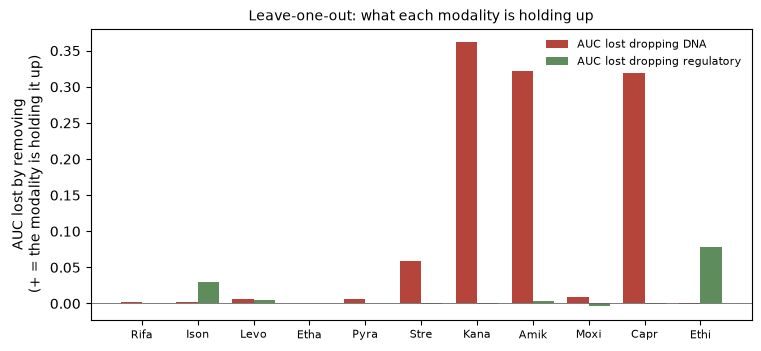


Spearman(DNA attribution share, AUC lost by dropping DNA) over 11 drugs: rho=+0.800  p=0.0031


,dna share,AUC lost dropping DNA
drug,,
KANAMYCIN,100.0%,+0.3622
AMIKACIN,99.7%,+0.3224
CAPREOMYCIN,84.4%,+0.3196
STREPTOMYCIN,23.8%,+0.0585
PYRAZINAMIDE,11.0%,+0.0066
ETHIONAMIDE,10.5%,-0.0004
LEVOFLOXACIN,9.0%,+0.0062
MOXIFLOXACIN,6.6%,+0.0087
ETHAMBUTOL,2.5%,+0.0009


In [60]:
LOO = ["dna", "regulatory_only", "no_dna", "no_regulatory", "all_modalities"]
have = [c for c in LOO if c in cv.columns]
if len(have) < 3:
    print(f"shap_followup runs not finished — have {have}.\n"
          "Check: squeue -u $USER | grep -E 'no_dna|no_regulatory|regulatory_only'")
else:
    t = cv[have].copy()
    # SAME sign convention as section 9: positive = removing it COSTS that much.
    if "no_dna" in t:
        t["AUC lost dropping DNA"] = t["all_modalities"] - t["no_dna"]
    if "no_regulatory" in t:
        t["AUC lost dropping regulatory"] = t["all_modalities"] - t["no_regulatory"]
    t = t.sort_values("all_modalities", ascending=False)
    costs = [c for c in t.columns if c.startswith("AUC lost")]
    # scale the gradient to the data: losses reach 0.36, so a fixed +/-0.05
    # window painted every rRNA drug the same saturated colour
    lim = float(np.nanmax(np.abs(t[costs].values))) if costs else 0.05
    display(t.style.format("{:.4f}", na_rep="—").background_gradient(
        cmap="RdYlGn_r", subset=costs, vmin=-lim, vmax=lim))

    if costs:
        fig, ax = plt.subplots(figsize=(7.5, 3.4), constrained_layout=True)
        w = 0.38
        x = np.arange(len(t))
        for i, c in enumerate(costs):
            ax.bar(x + i * w, t[c].values, w, label=c,
                   color=["#B5453A", "#5E8C5A"][i])
        ax.axhline(0, lw=0.6, color="0.4")
        ax.set_xticks(x + w / 2 * (len(costs) - 1))
        ax.set_xticklabels([d[:4].title() for d in t.index], fontsize=8)
        ax.set_ylabel("AUC lost by removing\n(+ = the modality is holding it up)")
        ax.set_title("Leave-one-out: what each modality is holding up", fontsize=10)
        ax.legend(fontsize=8, frameon=False)
        plt.show()

    # --- the sharpest test in the notebook ---------------------------------
    # Leave-one-out is what an attribution share should predict: SHAP measures
    # what the TRAINED model leans on, so a modality with a big share should be
    # the one whose removal hurts. `delta_add` asks a different question — what a
    # SEPARATELY trained model gains — and there is no reason a share should
    # track that. Ranking DNA share against the loss from dropping DNA tests the
    # claim on its own terms.
    dna_share = (sweep[(sweep["cell"] == "all_modalities") & (sweep["modality"] == "dna")]
                 .groupby("drug")["share"].sum())
    if "AUC lost dropping DNA" in t:
        j = pd.DataFrame({"dna share": dna_share,
                          "AUC lost dropping DNA": t["AUC lost dropping DNA"]}).dropna()
        if len(j) >= 4:
            r = spearmanr(j["dna share"], j["AUC lost dropping DNA"])
            print(f"\nSpearman(DNA attribution share, AUC lost by dropping DNA) "
                  f"over {len(j)} drugs: rho={r.statistic:+.3f}  p={r.pvalue:.4f}")
            display(j.sort_values("dna share", ascending=False)
                    .style.format({"dna share": "{:.1%}",
                                   "AUC lost dropping DNA": "{:+.4f}"}))

## 11. Named variants

`scripts/shap_attribution.py` cross-tabs every high-attribution column of a
one-hot block against phenotype over the **whole** test split, so a peak arrives
already named and already checked. For a protein block the column IS the residue
number, which is what turns "column 314" into *katG* 315.

This is the table to sanity-check the whole pipeline against: the model was
never told any biology, so a known resistance mutation appearing at the top is
evidence the attribution is reading something real.

In [61]:
col_files = sorted(SHAP_ROOT.glob("*/*__columns.csv"))
cols_all = pd.concat([pd.read_csv(p) for p in col_files], ignore_index=True)

# protein blocks first: their column index is a residue number, so they are the
# only ones that name a mutation without a coordinate walk
top = (cols_all[(cols_all["cell"] == "all_modalities")
                & (cols_all["modality"] == "protein")
                & (cols_all["alleles"] != "")]
       .sort_values("mean_abs_attr", ascending=False)
       .groupby("drug").head(2)
       .sort_values(["drug", "mean_abs_attr"], ascending=[True, False]))

display(top[["drug", "locus", "position_1based", "share_of_block", "alleles"]]
        .rename(columns={"position_1based": "residue", "share_of_block": "share"})
        .set_index(["drug", "locus"])
        .style.format({"share": "{:.1%}"}))

print("\nHighest-attribution nucleotide columns (alignment columns, NOT genome "
      "coordinates — a peak here still needs a coordinate walk to be named):")
nt = (cols_all[(cols_all["modality"].isin(["dna", "regulatory"]))
               & (cols_all["alleles"] != "")]
      .sort_values("mean_abs_attr", ascending=False)
      .groupby(["drug", "cell"]).head(1)
      .sort_values("mean_abs_attr", ascending=False))
display(nt[["drug", "cell", "block", "column", "share_of_block", "alleles"]]
        .set_index(["drug", "cell"])
        .style.format({"share_of_block": "{:.1%}"}))


Highest-attribution nucleotide columns (alignment columns, NOT genome coordinates — a peak here still needs a coordinate walk to be named):


---

# Part III — the joint model: right locus, right drug?

Everything above is **single-drug**: one model per drug, handed only that drug's
loci. It cannot look at the wrong gene because the wrong gene was never loaded.

The **joint** model (`multidrug_*`, `MDCNNNet` with `n_drugs=11`) is the
interesting case. It sees the **union of all 19 loci** in one pass and emits 11
logits from a shared trunk. Nothing in the architecture ties output column *j*
to any particular block — the head is free to key ISONIAZID off *rpoB* if that
happens to correlate in the cohort, and multi-drug resistance is heavily
correlated in TB, so it plausibly would.

**So: is it reading the right locus for the right drug?**

`scripts/shap_multidrug.py` attributes each of the 11 output columns separately
(`bash results/analysis/shap_multidrug/submit_shap_md.sh`) and scores the result
against `DRUG_TO_LOCI`. Two numbers per drug:

- **on-target share** — fraction of that drug's attribution landing on blocks
  whose locus is one of its own resistance genes.
- **enrichment** — on-target share divided by the share expected if attribution
  were spread evenly per position. Long genes would otherwise look on-target for
  free. **1.0 is chance; the model has to beat it.**

Targets are `DRUG_TO_LOCI` plus the `EXTRA_LOCI` overlay (*fabG1* for
INH/ETHIONAMIDE), since *fabG1* is WHO tier-1 for both and its absence from
`DRUG_TO_LOCI` would otherwise score a correct read as off-target.

In [62]:
# --- load the joint sweep --------------------------------------------------
MD_ROOT = PROJECT / "results" / "analysis" / "shap_multidrug" / RUN / ARCH
MD_CELLS = ["dna", "all_modalities"]

md_ontarget, md_locus, md_cols = {}, {}, {}
for cell in MD_CELLS:
    p = MD_ROOT / f"{cell}__ontarget.csv"
    if not p.exists():
        print(f"  {cell}: not on disk yet — "
              f"bash results/analysis/shap_multidrug/submit_shap_md.sh")
        continue
    md_ontarget[cell] = pd.read_csv(p).set_index("drug")
    md_locus[cell] = pd.read_csv(MD_ROOT / f"{cell}__drug_locus.csv")
    md_cols[cell] = pd.read_csv(MD_ROOT / f"{cell}__columns.csv")
    meta = json.loads((MD_ROOT / f"{cell}__meta.json").read_text())
    print(f"  {cell}: {meta['n_blocks']} blocks, {len(meta['drugs'])} drugs, "
          f"{meta['n_explained']} isolates, worst AUC delta "
          f"{meta['worst_auc_delta']:+.5f}")

if not md_ontarget:
    raise FileNotFoundError(f"no joint attribution in {MD_ROOT}")

  dna: 19 blocks, 11 drugs, 150 isolates, worst AUC delta +0.00005
  all_modalities: not on disk yet — bash results/analysis/shap_multidrug/submit_shap_md.sh


## 12. The drug x locus attribution matrix

One row per drug, one column per locus, cell = share of that drug's attribution.
**A model doing the right thing has a bright diagonal**: each drug's mass sitting
on its own genes (boxed).

DNA-only is the clean read. For the all-modalities cell the same locus appears
in up to four blocks (dna / protein / biophysical / regulatory), so shares are
summed per locus.

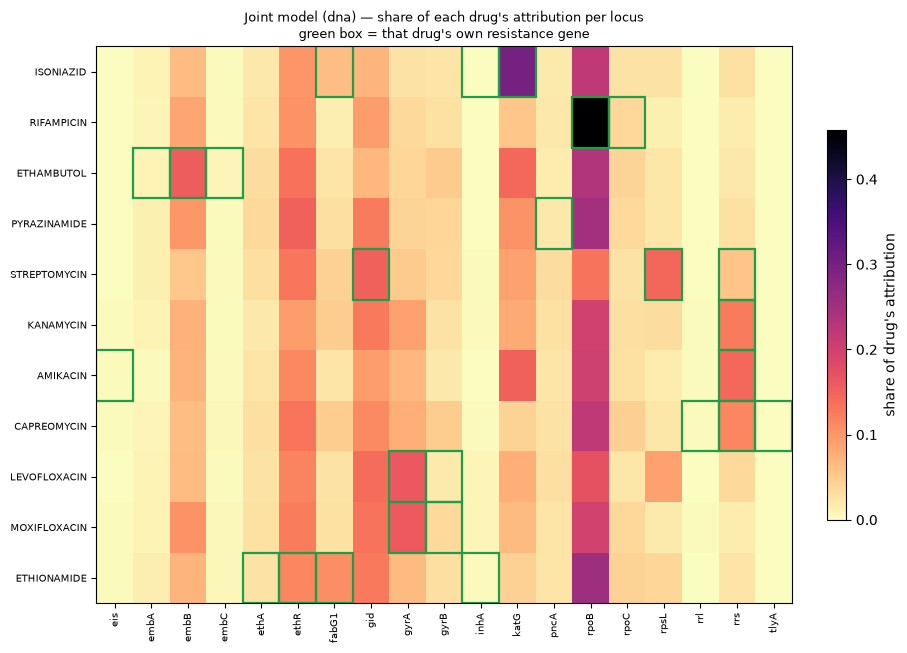

In [63]:
from matplotlib.patches import Rectangle

def locus_matrix(cell):
    # (drug x locus) share, summed over the modalities that carry that locus
    df = md_locus[cell]
    m = (df.groupby(["drug", "locus"])["share_of_drug"].sum()
           .unstack(fill_value=0.0))
    drugs = [d for d in md_ontarget[cell].index if d in m.index]
    return m.loc[drugs]


for cell in md_ontarget:
    m = locus_matrix(cell)
    targets = {d: set(str(v).split("+"))
               for d, v in md_ontarget[cell]["target_loci"].items()}

    fig, ax = plt.subplots(figsize=(1 + 0.42 * len(m.columns), 0.42 * len(m) + 1.8),
                           constrained_layout=True)
    im = ax.imshow(m.values, cmap="magma_r", vmin=0, vmax=min(1.0, m.values.max()),
                   aspect="auto")
    ax.set_xticks(range(len(m.columns)))
    ax.set_xticklabels(m.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(m)))
    ax.set_yticklabels(m.index, fontsize=7)
    # box every cell the drug is SUPPOSED to be reading
    for i, d in enumerate(m.index):
        for j, loc in enumerate(m.columns):
            if loc in targets.get(d, set()):
                ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                       edgecolor="#1f9e4a", lw=1.6))
    ax.set_title(f"Joint model ({cell}) — share of each drug's attribution per "
                 f"locus\ngreen box = that drug's own resistance gene", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.7, label="share of drug's attribution")
    plt.show()

## 13. On-target score

`enrichment > 1` means the drug's own genes get more attribution than their
share of sequence length. This is the headline number: it is the difference
between a joint model that has learned per-drug biology and one that has learned
"resistant isolates are resistant to everything".


=== dna


,on_target_share,null_share_by_length,enrichment,top_locus_is_on_target,target_loci,top_blocks
drug,,,,,,
STREPTOMYCIN,35.2%,8.7%,4.05x,True,gid+rpsL+rrs,"dna:gid(15%), dna:rpsL(15%), dna:rpoB(13%), dna:ethR(13%)"
ISONIAZID,36.2%,10.7%,3.38x,True,fabG1+inhA+katG,"dna:katG(30%), dna:rpoB(22%), dna:ethR(10%), dna:gid(7%)"
KANAMYCIN,12.7%,4.6%,2.77x,False,rrs,"dna:rpoB(20%), dna:gid(13%), dna:rrs(13%), dna:ethR(9%)"
RIFAMPICIN,49.5%,19.6%,2.52x,True,rpoB+rpoC,"dna:rpoB(46%), dna:ethR(10%), dna:gid(9%), dna:embB(8%)"
ETHIONAMIDE,25.2%,10.7%,2.35x,False,ethA+ethR+fabG1+inhA,"dna:rpoB(26%), dna:gid(13%), dna:ethR(11%), dna:fabG1(11%)"
AMIKACIN,14.8%,8.2%,1.81x,False,eis+rrs,"dna:rpoB(20%), dna:katG(15%), dna:rrs(14%), dna:ethR(11%)"
MOXIFLOXACIN,19.6%,12.0%,1.63x,False,gyrA+gyrB,"dna:rpoB(20%), dna:gyrA(16%), dna:gid(13%), dna:ethR(12%)"
LEVOFLOXACIN,18.1%,12.0%,1.51x,False,gyrA+gyrB,"dna:rpoB(17%), dna:gyrA(16%), dna:gid(14%), dna:ethR(12%)"
CAPREOMYCIN,11.9%,15.5%,0.76x,False,rrl+rrs+tlyA,"dna:rpoB(22%), dna:ethR(13%), dna:rrs(12%), dna:gid(11%)"


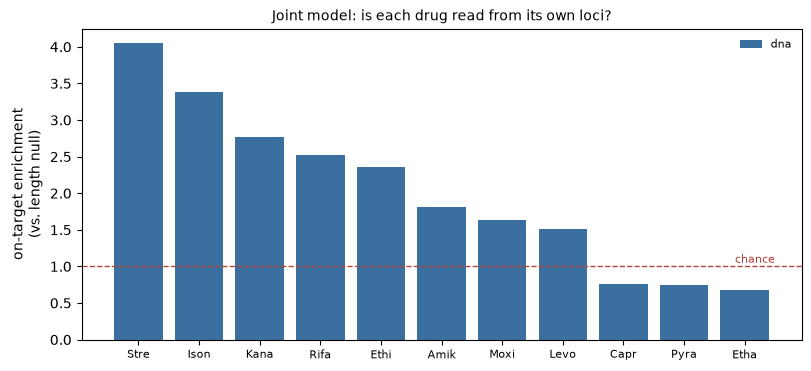

In [68]:
for cell in md_ontarget:
    t = md_ontarget[cell].sort_values("enrichment", ascending=False)
    print(f"\n=== {cell}")
    display(t[["on_target_share", "null_share_by_length", "enrichment",
               "top_locus_is_on_target", "target_loci", "top_blocks"]]
            .style.format({"on_target_share": "{:.1%}",
                           "null_share_by_length": "{:.1%}",
                           "enrichment": "{:.2f}x"}))

fig, ax = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
cells_have = list(md_ontarget)
order = md_ontarget[cells_have[0]].sort_values("enrichment", ascending=False).index
x = np.arange(len(order))
w = 0.8 / len(cells_have)
for i, cell in enumerate(cells_have):
    v = md_ontarget[cell]["enrichment"].reindex(order)
    ax.bar(x + i * w, v.values, w, label=cell,
           color=["#3B6FA0", "#C4703A"][i % 2])
ax.axhline(1.0, lw=1.0, color="#B5453A", ls="--")
ax.text(len(order) - 0.5, 1.05, "chance", color="#B5453A", fontsize=8, ha="right")
ax.set_xticks(x + w * (len(cells_have) - 1) / 2)
ax.set_xticklabels([d[:4].title() for d in order], fontsize=8)
ax.set_ylabel("on-target enrichment\n(vs. length null)")
ax.set_title("Joint model: is each drug read from its own loci?", fontsize=10)
ax.legend(fontsize=8, frameon=False)
plt.show()

## 14. Where the joint model looks off-target

Two very different reasons a drug's attribution lands on another gene, and they
need separating:

1. **Genuine cross-drug leakage** — the head exploiting phenotype correlation
   (MDR strains are resistant to INH *and* RIF), so RIFAMPICIN partly reads
   *katG*. That is a real failure of per-drug attribution and it will not
   generalise to a cohort with different co-resistance structure.
2. **Shared biology** — *rrs* really is the target of KANAMYCIN, AMIKACIN *and*
   CAPREOMYCIN; *inhA*/*fabG1* really is shared by ISONIAZID and ETHIONAMIDE.
   Attribution landing there is correct for both drugs.

The table below flags each off-target block by whether the locus belongs to some
*other* drug that this drug is commonly co-resistant with.

In [69]:
from datasets import DRUG_TO_LOCI

owner = {}
for d, loci in DRUG_TO_LOCI.items():
    for locus in loci:
        owner.setdefault(locus, []).append(d)

for cell in md_locus:
    df = md_locus[cell].copy()
    off = df[~df["on_target"]].groupby(["drug", "locus"])["share_of_drug"].sum()
    off = off[off > 0.02].reset_index().sort_values("share_of_drug", ascending=False)
    off["locus belongs to"] = off["locus"].map(
        lambda l: ", ".join(owner.get(l, ["(no drug)"])))
    print(f"\n=== {cell}: off-target loci taking >2% of a drug's attribution")
    if off.empty:
        print("  none — every drug's attribution is on its own loci")
    else:
        display(off.set_index(["drug", "locus"])
                .style.format({"share_of_drug": "{:.1%}"}))


=== dna: off-target loci taking >2% of a drug's attribution


,,share_of_drug,locus belongs to
drug,locus,,
ETHIONAMIDE,rpoB,25.5%,RIFAMPICIN
PYRAZINAMIDE,rpoB,25.0%,RIFAMPICIN
ETHAMBUTOL,rpoB,23.3%,RIFAMPICIN
CAPREOMYCIN,rpoB,21.9%,RIFAMPICIN
ISONIAZID,rpoB,21.8%,RIFAMPICIN
AMIKACIN,rpoB,20.1%,RIFAMPICIN
KANAMYCIN,rpoB,20.0%,RIFAMPICIN
MOXIFLOXACIN,rpoB,19.8%,RIFAMPICIN
LEVOFLOXACIN,rpoB,17.2%,RIFAMPICIN


## 15. Does the joint model find the same variants as the single-drug ones?

Part I found *katG* 315, *rpoB* 450, *gyrA* 94 and so on from 11 separate
models, each shown only its own gene. If the joint model — which had to *choose*
among 19 loci — lands on the same columns, that is independent confirmation from
a model with far more opportunity to go wrong.

In [66]:
for cell in md_cols:
    t = (md_cols[cell][md_cols[cell]["alleles"] != ""]
         .sort_values("mean_abs_attr", ascending=False)
         .groupby("drug").head(1)
         .sort_values("share_of_drug_total", ascending=False))
    print(f"\n=== {cell}: top attributed column per drug (joint model)")
    display(t[["drug", "block", "position_1based", "share_of_drug_total", "alleles"]]
            .rename(columns={"position_1based": "pos",
                             "share_of_drug_total": "share of drug"})
            .set_index("drug")
            .style.format({"share of drug": "{:.1%}"}))

# side-by-side with the single-drug sweep from Part II, where both exist
if "cols_all" in dir():
    sd = (cols_all[(cols_all["cell"] == "all_modalities")
                   & (cols_all["modality"] == "protein")
                   & (cols_all["alleles"] != "")]
          .sort_values("mean_abs_attr", ascending=False)
          .groupby("drug").head(1)
          .set_index("drug")[["locus", "position_1based"]]
          .rename(columns={"locus": "SD locus", "position_1based": "SD residue"}))
    cell = "all_modalities" if "all_modalities" in md_cols else list(md_cols)[0]
    jt = (md_cols[cell][md_cols[cell]["modality"] == "protein"]
          .sort_values("mean_abs_attr", ascending=False)
          .groupby("drug").head(1)
          .set_index("drug")[["locus", "position_1based"]]
          .rename(columns={"locus": "joint locus", "position_1based": "joint residue"}))
    cmp = sd.join(jt, how="inner")
    if not cmp.empty:
        cmp["same locus"] = cmp["SD locus"] == cmp["joint locus"]
        cmp["same residue"] = cmp["SD residue"] == cmp["joint residue"]
        print(f"\n=== single-drug vs joint ({cell}), top protein residue per drug")
        display(cmp)
        print(f"agree on locus: {cmp['same locus'].sum()}/{len(cmp)}   "
              f"agree on residue: {cmp['same residue'].sum()}/{len(cmp)}")


=== dna: top attributed column per drug (joint model)


,block,pos,share of drug,alleles
drug,,,,
RIFAMPICIN,dna:rpoB,1507,45.8%,T:97.7%R(n=596); G:90.0%R(n=20); -/pad:77.8%R(n=9); C:11.6%R(n=2896)
ISONIAZID,dna:katG,1074,30.0%,A:100.0%R(n=18); C:98.1%R(n=872); -/pad:64.3%R(n=14); G:11.5%R(n=2574)
MOXIFLOXACIN,dna:gyrA,281,16.0%,G:85.7%R(n=21); C:60.0%R(n=10); -/pad:60.0%R(n=5); A:11.5%R(n=520)
AMIKACIN,dna:katG,1074,15.1%,C:30.9%R(n=359); -/pad:30.0%R(n=10); G:10.2%R(n=342)
STREPTOMYCIN,dna:rpsL,240,14.6%,G:95.1%R(n=203); -/pad:50.0%R(n=6); A:23.4%R(n=1326)
ETHAMBUTOL,dna:katG,1074,14.5%,C:58.5%R(n=804); A:55.6%R(n=18); -/pad:35.7%R(n=14); G:5.3%R(n=2195)
KANAMYCIN,dna:rrs,1659,12.7%,-/pad:100.0%R(n=8); G:98.9%R(n=89); A:8.9%R(n=606)
CAPREOMYCIN,dna:rrs,1659,11.6%,G:86.2%R(n=94); -/pad:55.6%R(n=9); A:8.5%R(n=646)
ETHIONAMIDE,dna:fabG1,86,10.8%,T:65.5%R(n=84); C:20.8%R(n=355)


## Caveats and TODO

- **Attribution is not converged at low `NSAMPLES`.** The interactive ISONIAZID
  pass above used `NSAMPLES = 64` and split the budget protein 57% / biophysical
  36% / regulatory 6.5%. The sweep re-ran it at 128 and got protein 74% /
  biophysical 1.4% / **regulatory 23%** — same model, same isolates. The
  modality *ranking* moved, so treat any share from a low-sample run as
  provisional and re-run before quoting one. A convergence check (shares vs
  `NSAMPLES` = 32/64/128/256) is the missing experiment.
- **Alignment columns are not genome coordinates.** Protein blocks are the
  exception — there the column IS the residue number, which is why section 11
  can name *katG* 315 and *gyrA* 94. For DNA and regulatory blocks a peak still
  needs a walk through `datasets/sequences.py` back to an H37Rv coordinate.
- **One fold per model.** `FOLD = None` explains the single best-CV-fold model
  that TEST was scored on. Fold-to-fold attribution spread is unmeasured; with
  `--save-weights best` only that fold is on disk, so measuring it means a
  re-run with `--save-weights all`.
- **The derived modalities are not independent evidence.** protein and
  biophysical are computed *from* the same DNA, so their attribution share is a
  re-encoding, not new information. regulatory is the one modality read from
  separate FASTAs on disk. Sections 9-10 are what separate the two.
- **`mdcnn` merges DNA and regulatory into one trunk.** `MDCNNNet` groups blocks
  by channel count and both are 5-channel, so `dna_regulatory__mdcnn` already
  stacks the promoter windows as extra channels of the DNA trunk. Any experiment
  premised on giving regulatory "its own branch" needs
  `--mdcnn-trunk-per-modality`, which no recorded run uses.
- **The joint on-target score depends on `DRUG_TO_LOCI` being right.** It is the
  SD-CNN per-drug map plus the `EXTRA_LOCI` overlay (*fabG1*). A locus that is
  genuinely involved but unlisted scores as off-target, so read section 14
  before believing a low enrichment.
- **Shared loci are on-target for several drugs at once.** *rrs* belongs to
  KANAMYCIN, AMIKACIN and CAPREOMYCIN; *inhA*/*fabG1* to ISONIAZID and
  ETHIONAMIDE. High enrichment on a shared gene does not prove the joint model
  separates those drugs — a model that reads *rrs* and predicts all three
  aminoglycosides identically scores perfectly here. Distinguishing them needs
  the per-COLUMN comparison in section 15, not the locus-level score.